# Objectifs d'apprentissage – Semaine 3

À l'issue de cette semaine, l'étudiant sera capable de :

- **Expliquer** le théorème de Nyquist-Shannon et son importance.
- **Identifier** les conditions pour éviter le repliement de spectre (aliasing).
- **Simuler** l'échantillonnage et la reconstruction d'un signal.
- **Visualiser** l'effet de l'aliasing sur un signal sinusoïdal.
- **Comprendre** la quantification et l'erreur de quantification.
- **Calculer** le rapport signal sur bruit de quantification (SQNR).
- **Utiliser** Python pour générer des signaux échantillonnés et quantifiés.

# 1. Théorie de l'échantillonnage

L'échantillonnage est l'opération qui consiste à prélever des valeurs d'un signal continu à des instants réguliers.

## 1.1 Définition
Un signal continu $x(t)$ est échantillonné avec une période $T_e$ (secondes) pour donner une suite d'échantillons :
$$ x[n] = x(n T_e), \quad n \in \mathbb{Z} $$

La fréquence d'échantillonnage est $f_e = 1/T_e$ (en Hz).

## 1.2 Théorème de Nyquist-Shannon
Si un signal $x(t)$ est **à bande limitée** (c'est-à-dire que son spectre est nul au-delà d'une fréquence maximale $f_{max}$), alors il peut être parfaitement reconstruit à partir de ses échantillons si la fréquence d'échantillonnage vérifie :

$$ f_e > 2 f_{max} $$

La fréquence $f_N = 2 f_{max}$ est appelée **fréquence de Nyquist**.

Si cette condition n'est pas respectée, le signal subit un **repliement de spectre** (aliasing) : des composantes haute fréquence se superposent aux basses fréquences, rendant la reconstruction impossible.

### 1.3 Conséquences
- **Filtrage anti-repliement** : avant l'échantillonnage, il faut filtrer le signal pour éliminer toutes les fréquences au-delà de $f_e/2$.
- **Reconstruction** : un filtre passe-bas idéal de fréquence de coupure $f_e/2$ permet de reconstruire le signal original.

---

# 2. Illustration de l'aliasing en Python

Nous allons simuler l'échantillonnage d'un signal sinusoïdal à différentes fréquences d'échantillonnage pour observer le phénomène d'aliasing.

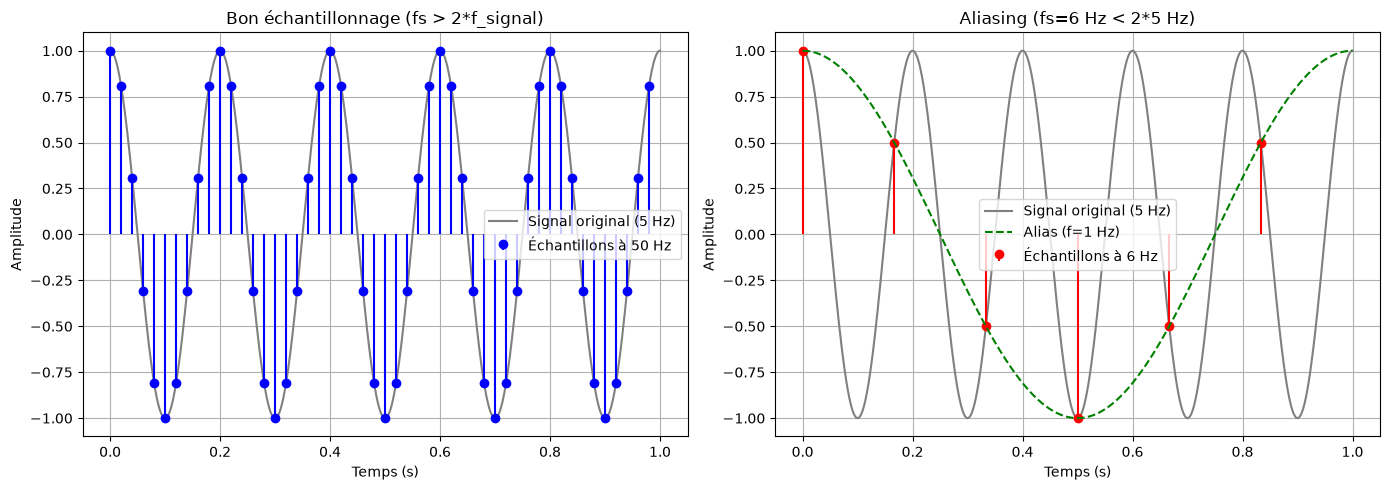

Le signal original à 5 Hz, échantillonné à 6 Hz, apparaît comme un signal à 1 Hz (alias).


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres
f_signal = 5  # Hz, fréquence du signal
fs = 50       # Hz, fréquence d'échantillonnage (bien au-dessus de 2*f_signal)
T = 1.0       # durée (s)

# Signal continu (simulé avec un pas fin)
t_cont = np.linspace(0, T, 1000)
x_cont = np.cos(2*np.pi*f_signal*t_cont)

# Échantillonnage correct
t_ech = np.arange(0, T, 1/fs)
x_ech = np.cos(2*np.pi*f_signal*t_ech)

# Sous-échantillonnage (aliasing)
fs_bad = 6  # Hz, inférieur à 2*f_signal
t_ech_bad = np.arange(0, T, 1/fs_bad)
x_ech_bad = np.cos(2*np.pi*f_signal*t_ech_bad)

# Visualisation
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(t_cont, x_cont, 'gray', label='Signal original (5 Hz)')
plt.stem(t_ech, x_ech, linefmt='b-', markerfmt='bo', basefmt=' ', label=f'Échantillons à {fs} Hz')
plt.title('Bon échantillonnage (fs > 2*f_signal)')
plt.xlabel('Temps (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(t_cont, x_cont, 'gray', label='Signal original (5 Hz)')
plt.stem(t_ech_bad, x_ech_bad, linefmt='r-', markerfmt='ro', basefmt=' ', label=f'Échantillons à {fs_bad} Hz')
# Tracer l'alias reconstruit (|fs_bad - f_signal| = 1 Hz)
f_alias = abs(fs_bad - f_signal)
x_alias = np.cos(2*np.pi*f_alias*t_cont)
plt.plot(t_cont, x_alias, 'g--', label=f'Alias (f={f_alias} Hz)')
plt.title(f'Aliasing (fs={fs_bad} Hz < 2*{f_signal} Hz)')
plt.xlabel('Temps (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Le signal original à {f_signal} Hz, échantillonné à {fs_bad} Hz, apparaît comme un signal à {f_alias} Hz (alias).")

# 3. Quantification

Après échantillonnage, l'amplitude de chaque échantillon est quantifiée sur un nombre fini de niveaux.

## 3.1 Principe
Un quantificateur à $N$ bits fournit $2^N$ niveaux de quantification. L'erreur de quantification $e_q[n] = x_q[n] - x[n]$ est généralement uniformément répartie entre $-\Delta/2$ et $\Delta/2$, où $\Delta$ est le pas de quantification.

## 3.2 Rapport signal sur bruit de quantification (SQNR)
Pour un signal sinusoïdal pleine échelle, le SQNR théorique est :
$$ \text{SQNR (dB)} = 6.02 N + 1.76 $$

---

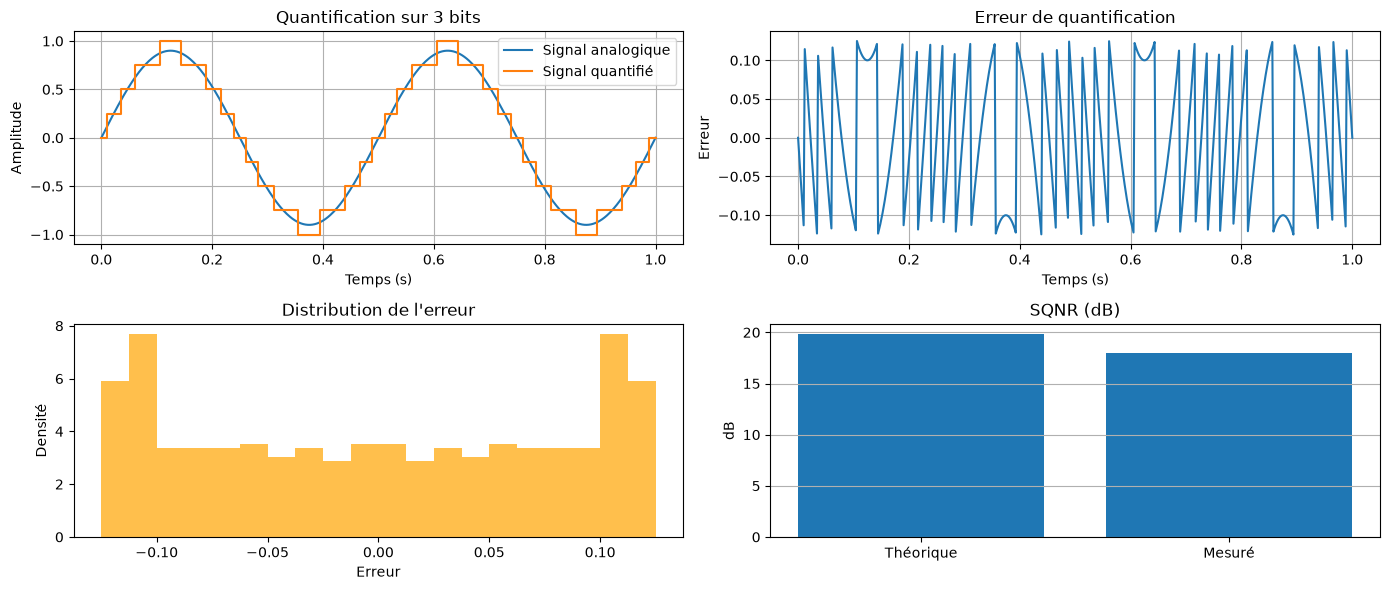

SQNR théorique : 19.82 dB
SQNR mesuré : 18.00 dB


In [2]:
# Simulation de quantification
N_bits = 3  # nombre de bits
levels = 2**N_bits

t = np.linspace(0, 1, 500)
x = 0.9 * np.sin(2*np.pi*2*t)  # signal analogique

# Quantification symétrique sur [-1, 1]
delta = 2 / levels
x_q = np.round(x / delta) * delta
x_q = np.clip(x_q, -1, 1)  # saturation

erreur = x_q - x

plt.figure(figsize=(14, 6))

plt.subplot(2, 2, 1)
plt.plot(t, x, label='Signal analogique')
plt.step(t, x_q, label='Signal quantifié', where='mid')
plt.title(f'Quantification sur {N_bits} bits')
plt.xlabel('Temps (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(t, erreur, label='Erreur de quantification')
plt.title('Erreur de quantification')
plt.xlabel('Temps (s)')
plt.ylabel('Erreur')
plt.grid(True)

plt.subplot(2, 2, 3)
plt.hist(erreur, bins=20, density=True, alpha=0.7, color='orange')
plt.title('Distribution de l\'erreur')
plt.xlabel('Erreur')
plt.ylabel('Densité')

# Calcul du SQNR théorique
sqnr_theorique = 6.02 * N_bits + 1.76
puissance_signal = np.mean(x**2)
puissance_bruit = np.mean(erreur**2)
sqnr_mesure = 10 * np.log10(puissance_signal / puissance_bruit)

plt.subplot(2, 2, 4)
plt.bar(['Théorique', 'Mesuré'], [sqnr_theorique, sqnr_mesure])
plt.title('SQNR (dB)')
plt.ylabel('dB')
plt.grid(True, axis='y')

plt.tight_layout()
plt.show()

print(f"SQNR théorique : {sqnr_theorique:.2f} dB")
print(f"SQNR mesuré : {sqnr_mesure:.2f} dB")

# 4. Exercices – Semaine 3

## Exercice 1 – Vérification du théorème de Nyquist
Soit $x(t) = \cos(2\pi 100 t) + 0.5\cos(2\pi 250 t)$.  
Quelle est la fréquence maximale du signal ?  
Quelle est la fréquence de Nyquist ?  
Si on échantillonne à $f_e = 300$ Hz, y a-t-il aliasing ?  
Si oui, quelles sont les fréquences apparentes des composantes après échantillonnage ?

**Solution** (à compléter) :

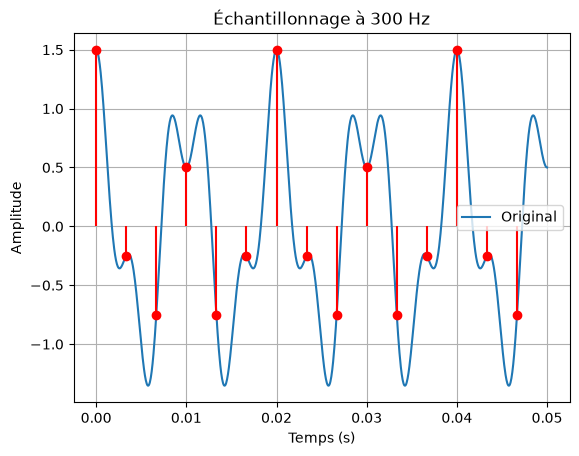

In [3]:
# Simulation
f1 = 100
f2 = 250
fe = 300
t = np.linspace(0, 0.05, 1000)
x = np.cos(2*np.pi*f1*t) + 0.5*np.cos(2*np.pi*f2*t)

# Échantillonnage
te = 1/fe
t_ech = np.arange(0, 0.05, te)
x_ech = np.cos(2*np.pi*f1*t_ech) + 0.5*np.cos(2*np.pi*f2*t_ech)

plt.plot(t, x, label='Original')
plt.stem(t_ech, x_ech, linefmt='r-', markerfmt='ro', basefmt=' ')
plt.xlabel('Temps (s)')
plt.ylabel('Amplitude')
plt.title('Échantillonnage à 300 Hz')
plt.grid()
plt.legend()
plt.show()

# Fréquences après aliasing : f1_alias = |f1 - k*fe|, f2_alias = |f2 - k*fe|
# Pour fe=300, f1=100 -> 100 Hz (inchangé), f2=250 -> |250-300|=50 Hz (alias)

## Exercice 2 – Quantification et SQNR
Un signal sinusoïdal pleine échelle (amplitude 1) est quantifié sur 8 bits.  
1. Calculer le pas de quantification $\Delta$ pour une plage $[-1, 1]$.  
2. Calculer le SQNR théorique.  
3. Simuler la quantification en Python pour différentes valeurs de $N$ (4, 8, 12, 16) et tracer le SQNR mesuré en fonction de $N$. Comparer avec la théorie.

**Code** :

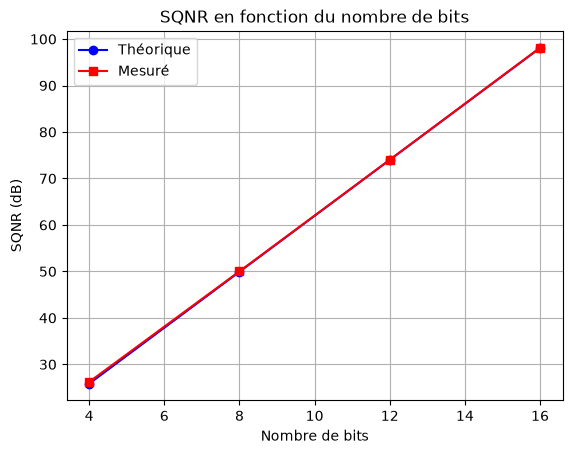

In [4]:
def quantifier(x, N_bits, amplitude=1.0):
    levels = 2**N_bits
    delta = 2*amplitude / levels
    x_q = np.round(x / delta) * delta
    x_q = np.clip(x_q, -amplitude, amplitude)
    return x_q, delta

t = np.linspace(0, 1, 10000)
x = np.sin(2*np.pi*10*t)  # signal test

Ns = [4, 8, 12, 16]
sqnr_mesures = []
sqnr_theoriques = []

for N in Ns:
    x_q, delta = quantifier(x, N)
    erreur = x_q - x
    P_s = np.mean(x**2)
    P_b = np.mean(erreur**2)
    sqnr = 10*np.log10(P_s / P_b)
    sqnr_mesures.append(sqnr)
    sqnr_theoriques.append(6.02*N + 1.76)

plt.plot(Ns, sqnr_theoriques, 'b-o', label='Théorique')
plt.plot(Ns, sqnr_mesures, 'r-s', label='Mesuré')
plt.xlabel('Nombre de bits')
plt.ylabel('SQNR (dB)')
plt.title('SQNR en fonction du nombre de bits')
plt.grid()
plt.legend()
plt.show()

## Exercice 3 – Reconstruction par interpolation
Utiliser les échantillons d'un signal sinusoïdal correctement échantillonné (ex: $f=5$ Hz, $f_e=50$ Hz) pour reconstruire le signal en utilisant une interpolation linéaire (ou une interpolation par sinus cardinal).  
Comparer la qualité de reconstruction avec l'original.

**Code** :

In [ ]:
def reconstruction_sinc(x_ech, t_ech, t_new, fe):
    """Reconstruction par interpolation sinc (idéale)."""
    x_recon = np.zeros_like(t_new)
    for i, t in enumerate(t_new):
        x_recon[i] = np.sum(x_ech * np.sinc(fe * (t - t_ech)))
    return x_recon

f_signal = 5
fe = 50
T = 1

t_cont = np.linspace(0, T, 1000)
x_cont = np.cos(2*np.pi*f_signal*t_cont)

t_ech = np.arange(0, T, 1/fe)
x_ech = np.cos(2*np.pi*f_signal*t_ech)

# Reconstruction par sinc
t_recon = np.linspace(0, T, 500)
x_recon = reconstruction_sinc(x_ech, t_ech, t_recon, fe)

plt.plot(t_cont, x_cont, label='Original')
plt.stem(t_ech, x_ech, linefmt='r-', markerfmt='ro', basefmt=' ', label='Échantillons')
plt.plot(t_recon, x_recon, 'g--', label='Reconstruction sinc')
plt.xlabel('Temps (s)')
plt.ylabel('Amplitude')
plt.title('Reconstruction par interpolation sinc')
plt.grid()
plt.legend()
plt.show()

## Exercice 4 – Effet du filtrage anti-aliasing
Créer un signal contenant des composantes à 20 Hz, 100 Hz et 200 Hz.  
Échantillonner à $f_e = 150$ Hz (sans filtre anti-aliasing).  
Quelles sont les composantes visibles après échantillonnage ?  
Appliquer un filtre passe-bas analogique avant échantillonnage (simulé) pour éliminer les fréquences > 75 Hz, puis échantillonner.  
Comparer les spectres des deux cas.

**Code** :

In [ ]:
from scipy.fft import fft, fftfreq

fs = 1000  # simulation haute résolution
t = np.linspace(0, 0.5, int(0.5*fs))

freqs_signal = [20, 100, 200]
x = np.sum([np.cos(2*np.pi*f*t) for f in freqs_signal], axis=0)

# Échantillonnage sans filtre
fe = 150
t_ech = np.arange(0, 0.5, 1/fe)
x_ech = np.sum([np.cos(2*np.pi*f*t_ech) for f in freqs_signal], axis=0)

# FFT des échantillons
N = len(x_ech)
freqs = fftfreq(N, 1/fe)
X_ech = fft(x_ech)

# Filtrage anti-aliasing (simulé : on garde uniquement les fréquences < fe/2)
x_filtre = np.sum([np.cos(2*np.pi*f*t) for f in freqs_signal if f < fe/2], axis=0)
# On échantillonne après filtrage
x_ech_filtre = np.sum([np.cos(2*np.pi*f*t_ech) for f in freqs_signal if f < fe/2], axis=0)
X_ech_filtre = fft(x_ech_filtre)

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.stem(freqs[:N//2], np.abs(X_ech[:N//2]) / N, basefmt=' ')
plt.title('Spectre des échantillons (sans filtre)')
plt.xlabel('Fréquence (Hz)')
plt.xlim(0, 120)
plt.grid()

plt.subplot(1, 2, 2)
plt.stem(freqs[:N//2], np.abs(X_ech_filtre[:N//2]) / N, basefmt=' ')
plt.title('Spectre des échantillons (avec filtre)')
plt.xlabel('Fréquence (Hz)')
plt.xlim(0, 120)
plt.grid()
plt.show()

# Explication : les fréquences > fe/2 (100 et 200 Hz) se replient sur 50 Hz et 100 Hz dans le premier cas.

# Livrable Semaine 3

- Remplir les cellules de code avec vos solutions.
- Répondre aux questions théoriques dans les cellules markdown.
- Inclure des commentaires explicatifs.
- Rendre le notebook complet (cellules exécutées).

**Date de rendu** : à définir par l'enseignant.